/tmp/ipykernel_2274/205386285.py:197: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.94])


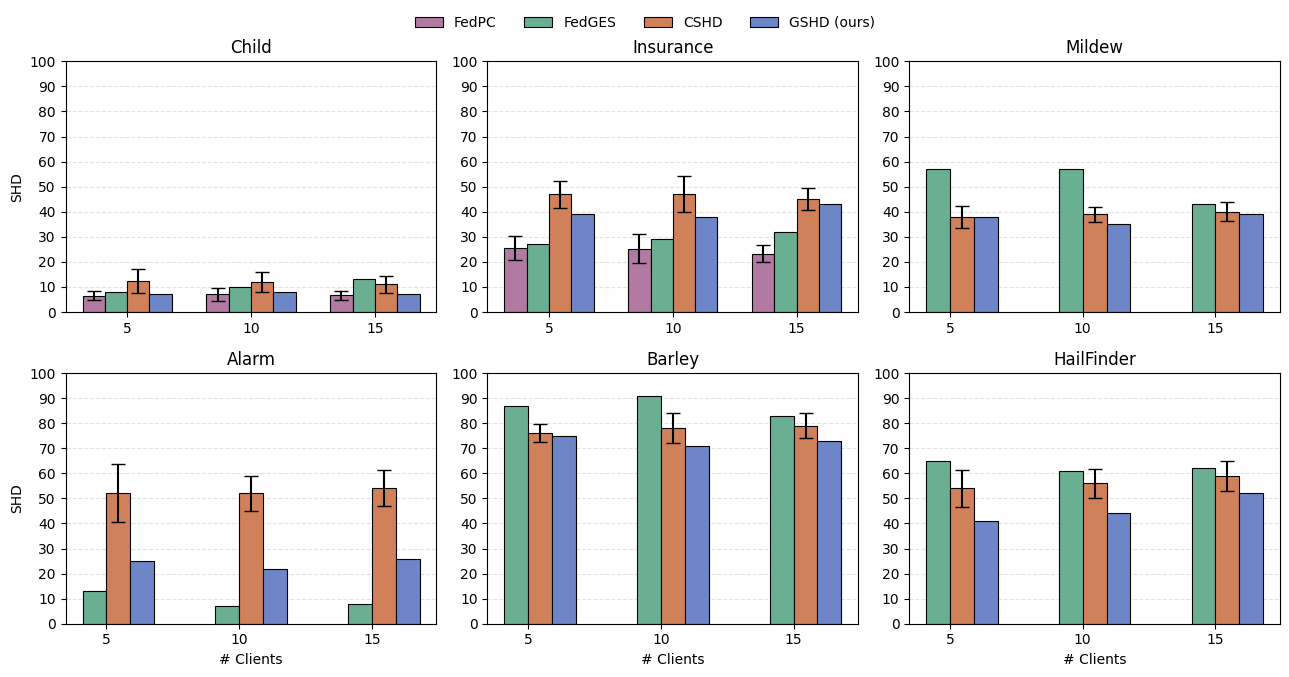

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Client counts
# -----------------------------
clients = ["5", "10", "15"]
x = np.arange(len(clients))
width = 0.25

# -----------------------------
# Data
# -----------------------------
cshd = {
    "Child":      [12.4, 12.0, 11.0],
    "Insurance":  [47.0, 47.0, 45.0],
    "Mildew":     [38.0, 39.0, 40.0],
    "Alarm":      [52.0, 52, 54],
    "Barley":     [76.0, 78, 79],
    "HailFinder": [54, 56, 59]
}

cshd_std = {
    "Child":      [4.67, 4.00, 3.464],
    "Insurance":  [5.385, 7.211, 4.472],
    "Mildew":     [4.472, 3.00, 3.741],
    "Alarm":      [11.576, 6.856, 7.141],
    "Barley":     [3.606, 6.082, 5.0],
    "HailFinder": [7.416, 5.831, 5.916]
}

gshd = {
    "Child":      [7, 8, 7],
    "Insurance":  [39, 38, 43],
    "Mildew":     [38, 35, 39],
    "Alarm":      [25, 22, 26],
    "Barley":     [75, 71, 73],
    "HailFinder": [41, 44, 52]
}

fedges = {
    "Child":      [8, 10, 13],
    "Insurance":  [27, 29, 32],
    "Mildew":     [57, 57, 43],
    "Alarm":      [13, 7, 8],
    "Barley":     [87, 91, 83],
    "HailFinder": [65, 61, 62]
}

fedpc_mean = {
    "Child":      [6.545, 7, 6.6],
    "Insurance":  [25.5, 25.3, 23.2],
    "Mildew":     [np.nan, np.nan, np.nan],
    "Alarm":      [np.nan, np.nan, np.nan],
    "Barley":     [np.nan, np.nan, np.nan],
    "HailFinder": [np.nan, np.nan, np.nan]
}

titles = list(cshd.keys())

# Colors
cshd_color   = "#D08159"   # terracotta
fedges_color = "#6BAF92"   # sea green
gshd_color   = "#6E86C7"   # steel blue
fedpc_color  = "#B279A2"   # dusty mauve

width = 0.18

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(cshd[network], dtype=float)
    std = np.array(cshd_std[network], dtype=float)

    global_shd = np.array(gshd[network], dtype=float)
    fedges_shd = np.array(fedges[network], dtype=float)

    fedpc_mean_vals = np.array(fedpc_mean[network], dtype=float)
    fedpc_std_vals  = np.array(fedpc_std[network], dtype=float)

    # -----------------------------
    # FedPC (leftmost)
    # -----------------------------
    ax.bar(
        x - 1.5 * width,
        fedpc_mean_vals,
        width,
        yerr=fedpc_std_vals,
        capsize=5,
        color=fedpc_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedPC",
    )

    # -----------------------------
    # FedGES
    # -----------------------------
    ax.bar(
        x - 0.5 * width,
        fedges_shd,
        width,
        color=fedges_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedGES",
    )

    # -----------------------------
    # CSHD
    # -----------------------------
    ax.bar(
        x + 0.5 * width,
        mean,
        width,
        yerr=std,
        capsize=5,
        color=cshd_color,
        edgecolor="black",
        linewidth=0.8,
        label="CSHD",
    )

    # -----------------------------
    # GSHD (rightmost)
    # -----------------------------
    ax.bar(
        x + 1.5 * width,
        global_shd,
        width,
        color=gshd_color,
        edgecolor="black",
        linewidth=0.8,
        label="GSHD (ours)",
    )

    ax.set_title(network, fontsize=12)

    # Show x-label only on bottom row
    if i >= 3:
        ax.set_xlabel("# Clients")

    # Show y-label only on first column
    if i % 3 == 0:
        ax.set_ylabel("SHD")

    ax.set_xticks(x)
    ax.set_xticklabels(clients)

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    # # Show legend only once
    # if i == 0:
    #     ax.legend(
    #         loc="upper center",
    #         bbox_to_anchor=(1.05, 1.22),
    #         ncol=4,
    #         frameon=False,
    #         fontsize=9,
    #     )
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=4,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

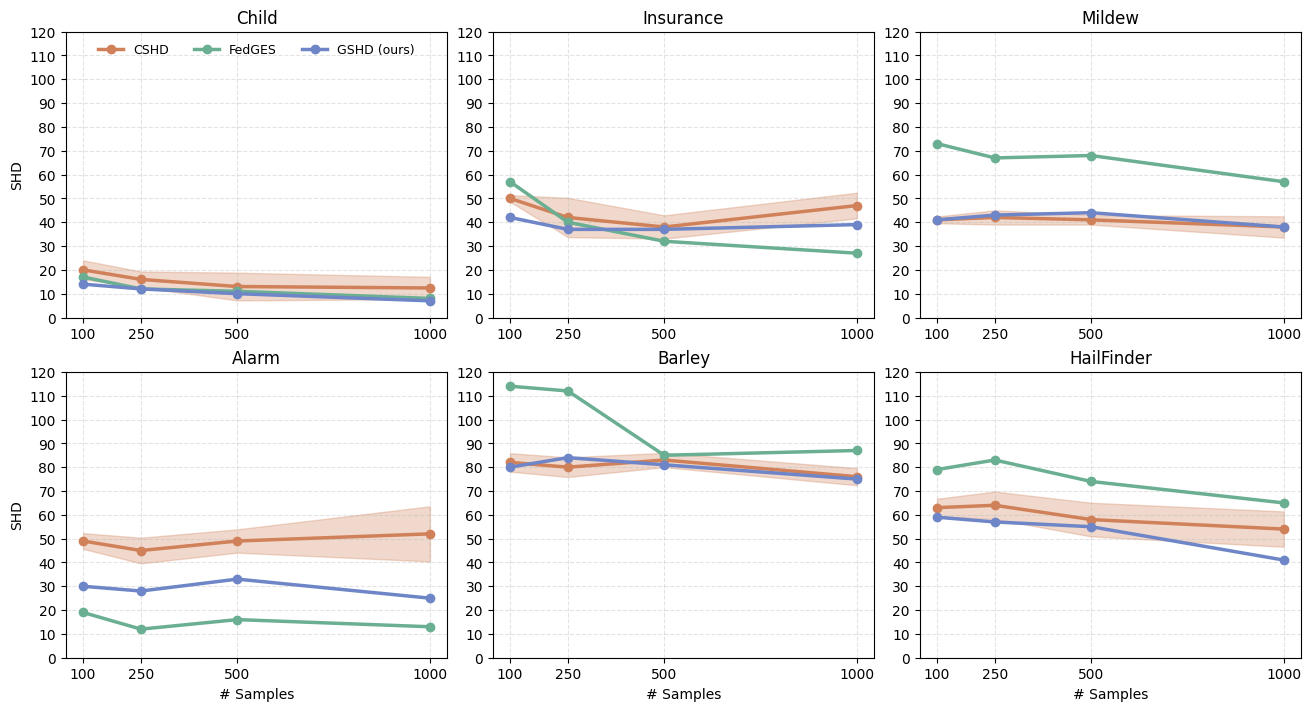

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Dataset sizes
# -----------------------------
sizes = np.array([100, 250, 500, 1000])

# -----------------------------
# CSHD
# -----------------------------
cshd = {
    "Child":      [20, 16, 13, 12.4],
    "Insurance":  [50, 42, 38, 47],
    "Mildew":     [41, 42, 41, 38],
    "Alarm":      [49, 45, 49, 52],
    "Barley":     [82, 80, 83, 76],
    "HailFinder": [63, 64, 58, 54],
}

cshd_std = {
    "Child":      [4.0, 3.316, 5.831, 4.67],
    "Insurance":  [1.414, 8.246, 4.899, 5.385],
    "Mildew":     [1.414, 3.0, 2.0, 4.472],
    "Alarm":      [3.317, 5.385, 4.899, 11.576],
    "Barley":     [3.873, 4.123, 3.0, 3.606],
    "HailFinder": [3.742, 5.745, 7.071, 7.416],
}

# -----------------------------
# GSHD
# -----------------------------
gshd = {
    "Child":      [14, 12, 10, 7],
    "Insurance":  [42, 37, 37, 39],
    "Mildew":     [41, 43, 44, 38],
    "Alarm":      [30, 28, 33, 25],
    "Barley":     [80, 84, 81, 75],
    "HailFinder": [59, 57, 55, 41],
}

# -----------------------------
# FedGES (fill later)
# -----------------------------
fedges = {
    "Child":      [17, 12, 11, 8],
    "Insurance":  [57, 40, 32, 27],
    "Mildew":     [73, 67, 68, 57],
    "Alarm":      [19, 12, 16, 13],
    "Barley":     [114, 112, 85, 87],
    "HailFinder": [79, 83, 74, 65],
}

titles = list(cshd.keys())

cshd_color   = "#D08159"   # terracotta
fedges_color = "#6BAF92"   # sea green
gshd_color   = "#6E86C7"   # steel blue

fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(cshd[network], dtype=float)
    std = np.array(cshd_std[network], dtype=float)
    fed = np.array(fedges[network], dtype=float)
    g = np.array(gshd[network], dtype=float)

    # CSHD
    ax.plot(
        sizes,
        mean,
        color=cshd_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="CSHD",
    )

    # Variance band
    ax.fill_between(
        sizes,
        mean - std,
        mean + std,
        color=cshd_color,
        alpha=0.30,
    )

    # FedGES
    ax.plot(
        sizes,
        fed,
        color=fedges_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedGES",
    )

    # GSHD
    ax.plot(
        sizes,
        g,
        color=gshd_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="GSHD (ours)",
    )

    ax.set_title(network)
    if i >= 3:      # bottom row
        ax.set_xlabel("# Samples")
    else:
        ax.set_xlabel("")

    if i % 3 == 0:      # first column
        ax.set_ylabel("SHD")
    else:
        ax.set_ylabel("")

    ax.set_xticks(sizes)

    ax.set_ylim(0, 120)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(True, linestyle="--", alpha=0.35)

    if i == 0:
        ax.legend(
            loc="upper center",
            ncol=3,
            frameon=False,
            fontsize=9,
        )

plt.show()

/tmp/ipykernel_221193/3510808710.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.94])


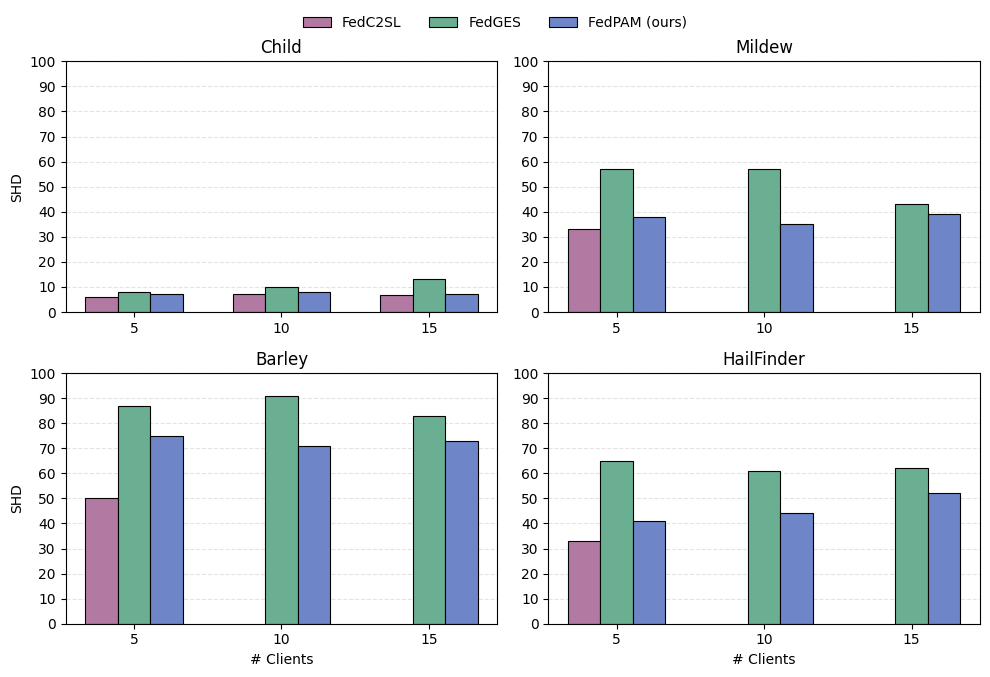

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Client counts
# -----------------------------
clients = ["5", "10", "15"]
x = np.arange(len(clients))

# -----------------------------
# Data - only keeping Child, Mildew, Barley, HailFinder
# -----------------------------
gshd = {
    "Child":      [7, 8, 7],
    "Mildew":     [38, 35, 39],
    "Barley":     [75, 71, 73],
    "HailFinder": [41, 44, 52]
}

fedges = {
    "Child":      [8, 10, 13],
    "Mildew":     [57, 57, 43],
    "Barley":     [87, 91, 83],
    "HailFinder": [65, 61, 62]
}

fedpc_mean = {
    "Child":      [6, 7, 6.6],
    "Mildew":     [33, 24, 22],
    "Barley":     [50, 42, 39],
    "HailFinder": [33, 34, 35]
}


titles = list(gshd.keys())

# Colors
fedpc_color  = "#B279A2"   # dusty mauve
fedges_color = "#6BAF92"   # sea green
fedpam_color = "#6E86C7"   # steel blue

width = 0.22

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    fedpam_shd = np.array(gshd[network], dtype=float)
    fedges_shd = np.array(fedges[network], dtype=float)
    fedpc_mean_vals = np.array(fedpc_mean[network], dtype=float)

    # -----------------------------
    # FedPC (leftmost)
    # -----------------------------
    ax.bar(
        x - width,
        fedpc_mean_vals,
        width,
        color=fedpc_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedC2SL",
    )

    # -----------------------------
    # FedGES (middle)
    # -----------------------------
    ax.bar(
        x,
        fedges_shd,
        width,
        color=fedges_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedGES",
    )

    # -----------------------------
    # FedPAM (rightmost) - renamed from GSHD
    # -----------------------------
    ax.bar(
        x + width,
        fedpam_shd,
        width,
        color=fedpam_color,
        edgecolor="black",
        linewidth=0.8,
        label="FedPAM (ours)",
    )

    ax.set_title(network, fontsize=12)

    # Show x-label only on bottom row
    if i >= 2:
        ax.set_xlabel("# Clients")

    # Show y-label only on first column
    if i % 2 == 0:
        ax.set_ylabel("SHD")

    ax.set_xticks(x)
    ax.set_xticklabels(clients)

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.97),
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('IMPACT_NUM_CLIENTS.png', dpi=1000, bbox_inches='tight')
plt.show()

/tmp/ipykernel_221193/3177662548.py:124: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


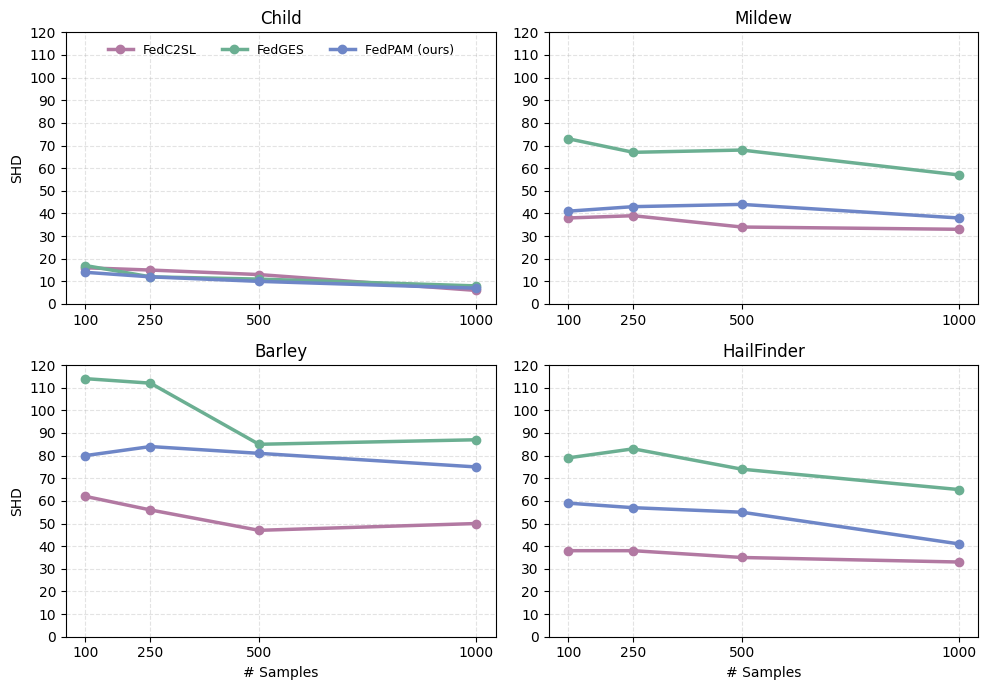

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Dataset sizes
# -----------------------------
sizes = np.array([100, 250, 500, 1000])

# -----------------------------
# FedPC (renamed from CSHD)
# -----------------------------
fedpc = {
    "Child":      [16, 15, 13, 6],
    "Mildew":     [38, 39, 34, 33],
    "Barley":     [62, 56, 47, 50],
    "HailFinder": [38, 38, 35, 33]
}


# -----------------------------
# FedPAM (renamed from GSHD)
# -----------------------------
fedpam = {
    "Child":      [14, 12, 10, 7],
    "Mildew":     [41, 43, 44, 38],
    "Barley":     [80, 84, 81, 75],
    "HailFinder": [59, 57, 55, 41],
}

# -----------------------------
# FedGES
# -----------------------------
fedges = {
    "Child":      [17, 12, 11, 8],
    "Mildew":     [73, 67, 68, 57],
    "Barley":     [114, 112, 85, 87],
    "HailFinder": [79, 83, 74, 65],
}

titles = list(fedpc.keys())

fedpc_color   = "#B279A2"   # dusty mauve
fedges_color  = "#6BAF92"   # sea green
fedpam_color  = "#6E86C7"   # steel blue

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    constrained_layout=True
)

axes = axes.flatten()

for i, network in enumerate(titles):

    ax = axes[i]

    mean = np.array(fedpc[network], dtype=float)
    std = np.array(fedpc_std[network], dtype=float)
    fed = np.array(fedges[network], dtype=float)
    pam = np.array(fedpam[network], dtype=float)

    # FedPC
    ax.plot(
        sizes,
        mean,
        color=fedpc_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedC2SL",
    )

    # FedGES
    ax.plot(
        sizes,
        fed,
        color=fedges_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedGES",
    )

    # FedPAM
    ax.plot(
        sizes,
        pam,
        color=fedpam_color,
        linewidth=2.5,
        marker='o',
        markersize=6,
        label="FedPAM (ours)",
    )

    ax.set_title(network, fontsize=12)
    
    if i >= 2:      # bottom row
        ax.set_xlabel("# Samples")
    else:
        ax.set_xlabel("")

    if i % 2 == 0:      # first column
        ax.set_ylabel("SHD")
    else:
        ax.set_ylabel("")

    ax.set_xticks(sizes)

    ax.set_ylim(0, 120)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.grid(True, linestyle="--", alpha=0.35)

    if i == 0:
        ax.legend(
            loc="upper center",
            ncol=3,
            frameon=False,
            fontsize=9,
        )

plt.tight_layout()
plt.savefig('IMPACT_NUM_SAMPLES.png', dpi=1000, bbox_inches='tight')
plt.show()

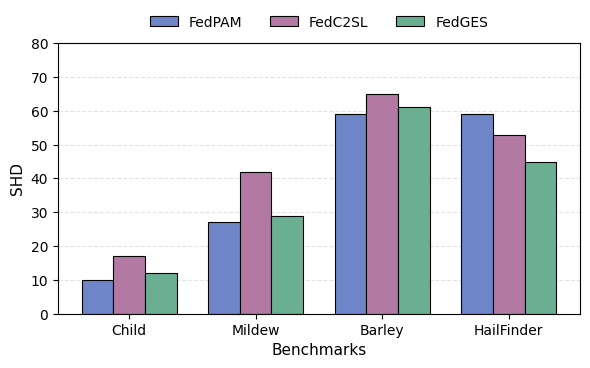

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Benchmarks
benchmarks = ["Child", "Mildew", "Barley", "HailFinder"]
x = np.arange(len(benchmarks))

# Data
fedpam = [10, 27, 59, 59]
fedc2sl = [17, 42, 65, 53]
fedges = [12, 29, 61, 45]

# Colors
fedpam_color = "#6E86C7"   # steel blue
fedc2sl_color = "#B279A2"  # dusty mauve
fedges_color = "#6BAF92"   # sea green

width = 0.25

fig, ax = plt.subplots(figsize=(6, 4))

# Plot bars
ax.bar(
    x - width,
    fedpam,
    width,
    color=fedpam_color,
    edgecolor="black",
    linewidth=0.8,
    label="FedPAM",
)

ax.bar(
    x,
    fedc2sl,
    width,
    color=fedc2sl_color,
    edgecolor="black",
    linewidth=0.8,
    label="FedC2SL",
)

ax.bar(
    x + width,
    fedges,
    width,
    color=fedges_color,
    edgecolor="black",
    linewidth=0.8,
    label="FedGES",
)

# Labels and formatting
ax.set_xlabel("Benchmarks", fontsize=11)
ax.set_ylabel("SHD", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(benchmarks)
ax.set_ylim(0, 80)
ax.yaxis.set_major_locator(MultipleLocator(10))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),  # move legend up
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('heterogeneous_data.png', dpi=1000, bbox_inches='tight')
plt.show()